# Regresión Logística

## Prepara datos

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Manejo de archivos y carpetas
import os

# Computación numérica
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# Mostrar gráficos dentro del notebook
%matplotlib inline

In [3]:
import pandas as pd
import numpy as np

data = pd.read_csv('/content/drive/MyDrive/SIS420/datasets/datasets_tareas/heart_2022_no_nans.csv')

print(data.head())

     State     Sex GeneralHealth  PhysicalHealthDays  MentalHealthDays  \
0  Alabama  Female     Very good                 4.0               0.0   
1  Alabama    Male     Very good                 0.0               0.0   
2  Alabama    Male     Very good                 0.0               0.0   
3  Alabama  Female          Fair                 5.0               0.0   
4  Alabama  Female          Good                 3.0              15.0   

                                     LastCheckupTime PhysicalActivities  \
0  Within past year (anytime less than 12 months ...                Yes   
1  Within past year (anytime less than 12 months ...                Yes   
2  Within past year (anytime less than 12 months ...                 No   
3  Within past year (anytime less than 12 months ...                Yes   
4  Within past year (anytime less than 12 months ...                Yes   

   SleepHours            RemovedTeeth HadHeartAttack  ... HeightInMeters  \
0         9.0            Non

In [4]:
print(data.dtypes)

State                         object
Sex                           object
GeneralHealth                 object
PhysicalHealthDays           float64
MentalHealthDays             float64
LastCheckupTime               object
PhysicalActivities            object
SleepHours                   float64
RemovedTeeth                  object
HadHeartAttack                object
HadAngina                     object
HadStroke                     object
HadAsthma                     object
HadSkinCancer                 object
HadCOPD                       object
HadDepressiveDisorder         object
HadKidneyDisease              object
HadArthritis                  object
HadDiabetes                   object
DeafOrHardOfHearing           object
BlindOrVisionDifficulty       object
DifficultyConcentrating       object
DifficultyWalking             object
DifficultyDressingBathing     object
DifficultyErrands             object
SmokerStatus                  object
ECigaretteUsage               object
C

In [5]:
print(data.isnull().sum())

State                        0
Sex                          0
GeneralHealth                0
PhysicalHealthDays           0
MentalHealthDays             0
LastCheckupTime              0
PhysicalActivities           0
SleepHours                   0
RemovedTeeth                 0
HadHeartAttack               0
HadAngina                    0
HadStroke                    0
HadAsthma                    0
HadSkinCancer                0
HadCOPD                      0
HadDepressiveDisorder        0
HadKidneyDisease             0
HadArthritis                 0
HadDiabetes                  0
DeafOrHardOfHearing          0
BlindOrVisionDifficulty      0
DifficultyConcentrating      0
DifficultyWalking            0
DifficultyDressingBathing    0
DifficultyErrands            0
SmokerStatus                 0
ECigaretteUsage              0
ChestScan                    0
RaceEthnicityCategory        0
AgeCategory                  0
HeightInMeters               0
WeightInKilograms            0
BMI     

In [6]:
num_cols = data.select_dtypes(include=['float64','int64']).columns

for col in num_cols:
    data[col] = data[col].fillna(data[col].mean())

In [7]:
print(data.isnull().sum().sum())

0


In [8]:
# Y elegida HadHeartAttack, convertir el yes/no a 1/0
data['HadHeartAttack'] = data['HadHeartAttack'].map({'Yes':1, 'No':0})

In [9]:
print(data['HadHeartAttack'].head())

0    0
1    0
2    0
3    0
4    0
Name: HadHeartAttack, dtype: int64


In [10]:
print(data.select_dtypes(include=['object']).columns)

Index(['State', 'Sex', 'GeneralHealth', 'LastCheckupTime',
       'PhysicalActivities', 'RemovedTeeth', 'HadAngina', 'HadStroke',
       'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder',
       'HadKidneyDisease', 'HadArthritis', 'HadDiabetes',
       'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus',
       'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos'],
      dtype='object')


In [11]:
data = pd.get_dummies(data)

# Convertir strings a números
# Esto transforma columnas como:Sex
# En: Sex_Female; Sex_Male

In [12]:
for col in data.columns:
    print(col, data[col].dtype)

PhysicalHealthDays float64
MentalHealthDays float64
SleepHours float64
HadHeartAttack int64
HeightInMeters float64
WeightInKilograms float64
BMI float64
State_Alabama bool
State_Alaska bool
State_Arizona bool
State_Arkansas bool
State_California bool
State_Colorado bool
State_Connecticut bool
State_Delaware bool
State_District of Columbia bool
State_Florida bool
State_Georgia bool
State_Guam bool
State_Hawaii bool
State_Idaho bool
State_Illinois bool
State_Indiana bool
State_Iowa bool
State_Kansas bool
State_Kentucky bool
State_Louisiana bool
State_Maine bool
State_Maryland bool
State_Massachusetts bool
State_Michigan bool
State_Minnesota bool
State_Mississippi bool
State_Missouri bool
State_Montana bool
State_Nebraska bool
State_Nevada bool
State_New Hampshire bool
State_New Jersey bool
State_New Mexico bool
State_New York bool
State_North Carolina bool
State_North Dakota bool
State_Ohio bool
State_Oklahoma bool
State_Oregon bool
State_Pennsylvania bool
State_Puerto Rico bool
State_Rh

In [13]:
X = data.drop('HadHeartAttack', axis=1)
y = data['HadHeartAttack']

In [14]:
X = X.values
y = y.values

In [15]:
print("X:", X.shape)
print("y:", y.shape)

X: (246022, 154)
y: (246022,)


## Gráfico

In [16]:
# Tomar una muestra de 2000 filas
sample = data.sample(n=2000, random_state=1)

In [17]:
X_plot = sample[['BMI', 'SleepHours']].values
y_plot = sample['HadHeartAttack'].values

In [18]:
def plotData(X, y):

    fig = pyplot.figure()

    pos = y == 1
    neg = y == 0

    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=10)
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1)

    pyplot.xlabel("BMI")
    pyplot.ylabel("Sleep Hours")

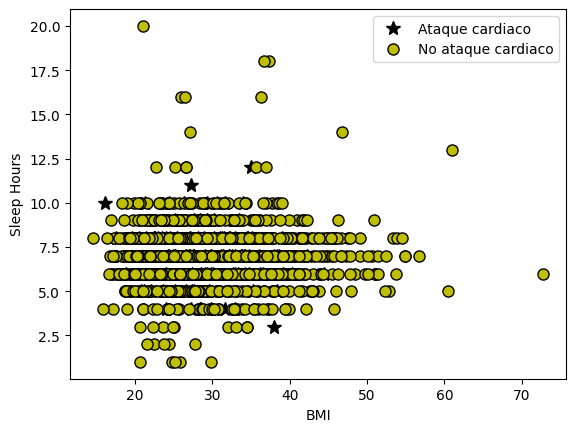

In [19]:
# Graficar
plotData(X_plot, y_plot)

pyplot.legend(['Ataque cardiaco', 'No ataque cardiaco'])

pyplot.show()

## Implementación

In [20]:
# Boleanos a enteros

for col in data.columns:
    print(col, data[col].dtype)

PhysicalHealthDays float64
MentalHealthDays float64
SleepHours float64
HadHeartAttack int64
HeightInMeters float64
WeightInKilograms float64
BMI float64
State_Alabama bool
State_Alaska bool
State_Arizona bool
State_Arkansas bool
State_California bool
State_Colorado bool
State_Connecticut bool
State_Delaware bool
State_District of Columbia bool
State_Florida bool
State_Georgia bool
State_Guam bool
State_Hawaii bool
State_Idaho bool
State_Illinois bool
State_Indiana bool
State_Iowa bool
State_Kansas bool
State_Kentucky bool
State_Louisiana bool
State_Maine bool
State_Maryland bool
State_Massachusetts bool
State_Michigan bool
State_Minnesota bool
State_Mississippi bool
State_Missouri bool
State_Montana bool
State_Nebraska bool
State_Nevada bool
State_New Hampshire bool
State_New Jersey bool
State_New Mexico bool
State_New York bool
State_North Carolina bool
State_North Dakota bool
State_Ohio bool
State_Oklahoma bool
State_Oregon bool
State_Pennsylvania bool
State_Puerto Rico bool
State_Rh

In [21]:
X = data.drop('HadHeartAttack', axis=1)
y = data['HadHeartAttack']

X = X.astype(float).values
y = y.astype(float).values

print(X.dtype)
print(y.dtype)

float64
float64


In [22]:
# Función sigmoide

def sigmoid(z):
    z = np.array(z)
    g = 1 / (1 + np.exp(-z))
    return g

In [23]:
# Columna de unos
m, n = X.shape
X = np.concatenate([np.ones((m,1)), X], axis=1)

n_features = X.shape[1]        # 155 (154 features + 1 bias)
initial_theta = np.zeros(n_features)

print("n_features:", n_features)
print("initial_theta shape:", initial_theta.shape)

n_features: 155
initial_theta shape: (155,)


## Función predictiva

In [24]:
# Función costo
def calcularAtaque(theta, X, y):

    m = y.size

    h = sigmoid(X.dot(theta))
    J = (1/m) * np.sum(-y*np.log(h) - (1-y)*np.log(1-h))

    return J

In [25]:
# Descenso gradiente
def descensoGradiente(theta, X, y, alpha, num_iters):

    m = y.shape[0]

    theta = theta.copy()
    J_history = []

    for i in range(num_iters):

        h = sigmoid(X.dot(theta))

        theta = theta - (alpha/m) * (X.T.dot(h - y))

        J_history.append(calcularAtaque(theta, X, y))

    return theta, J_history

In [26]:
# Entrenar el modelo

alpha = 0.001
num_iters = 80000

theta = np.zeros(X.shape[1])

theta, J_history = descensoGradiente(theta, X, y, alpha, num_iters)


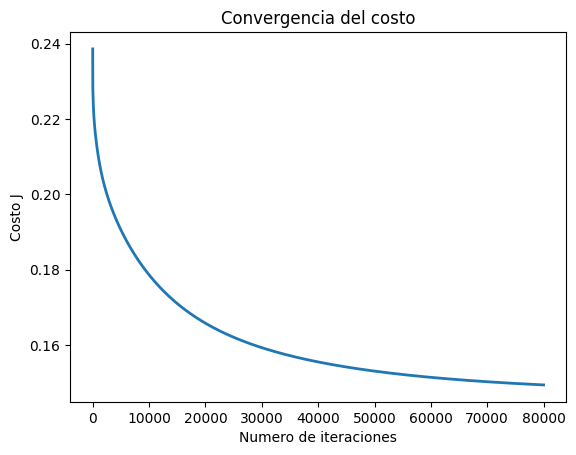

Theta calculado:
[-6.48322641e-02  3.04465654e-03 -2.79547753e-03 -1.51352002e-02
 -1.07468681e-01  8.47980287e-04 -1.21144782e-02 -3.20223882e-03
  2.04928948e-03  1.01092266e-02  6.75436938e-03 -6.14526249e-03
 -3.75314556e-03 -6.75470393e-03 -5.62718501e-03 -4.44344735e-03
  1.68487705e-02 -8.75414902e-03 -5.38948430e-04 -9.37467577e-03
 -1.01232477e-03 -5.58587611e-03 -4.83694161e-04 -7.16220060e-03
 -3.82743820e-03 -2.10291702e-03 -2.78839780e-03  2.04710454e-02
 -6.26026682e-03 -1.88211930e-03  6.51012770e-04 -1.36502548e-02
 -3.40666569e-03 -4.49489968e-03  2.73472260e-03  1.38986347e-02
  1.68827145e-03  8.79587887e-03 -8.98100027e-03  4.16445467e-03
 -1.70849958e-02 -1.50294161e-03  4.14941888e-04  1.08020063e-02
  2.91634556e-04 -1.82235109e-03 -2.21168855e-03 -4.90384044e-03
 -1.27608371e-03 -1.23547267e-02  1.70936610e-02 -1.81395218e-03
  2.22149393e-03 -8.74737977e-03  4.50193980e-03 -1.48672694e-03
 -4.53748313e-03 -1.71038500e-02  3.82830551e-03 -4.08176705e-03
 -2.9923

In [27]:
# Grafica la convergencia
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del costo')
pyplot.show()

# Mostrar theta
print("Theta calculado:")
print(theta)

# probar con un ejemplo del dataset
ejemplo = X[0]

prob = sigmoid(np.dot(ejemplo, theta))

print("Probabilidad de ataque cardiaco:", prob)

pred = prob >= 0.5

if pred:
    print("Predicción: Ataque cardiaco")
else:
    print("Predicción: No ataque cardiaco")

# accuracy del modelo
predicciones = sigmoid(X.dot(theta)) >= 0.5
accuracy = np.mean(predicciones == y) * 100

print("Accuracy del modelo:", accuracy, "%")

In [28]:
def evaluar_riesgo(theta, columnas):

    print("\n=== Evaluación de Riesgo de Ataque Cardíaco ===\n")

    # Crear vector de entrada con todos los atributos en 0
    x_input = np.zeros(len(columnas) + 1)

    # bias
    x_input[0] = 1

    # ====== preguntas ======

    bmi = float(input("1) BMI (ej: 26): "))
    sleep = float(input("2) Horas de sueño por noche: "))
    phys = float(input("3) Días de mala salud física en el último mes: "))
    mental = float(input("4) Días de mala salud mental en el último mes: "))
    peso = float(input("5) Peso en kg: "))
    altura = float(input("6) Altura en metros (ej: 1.75): "))

    fuma = input("7) ¿Fuma? (s/n): ")
    riesgo = input("8) ¿Tuvo una condición de alto riesgo el último año? (s/n): ")
    covid = input("9) ¿Tuvo COVID positivo? (s/n): ")
    alcohol = input("10) ¿Consume alcohol regularmente? (s/n): ")

    # ====== insertar datos ======

    def set_val(col, val):
        if col in columnas:
            x_input[columnas.index(col) + 1] = val

    set_val("BMI", bmi)
    set_val("SleepHours", sleep)
    set_val("PhysicalHealthDays", phys)
    set_val("MentalHealthDays", mental)
    set_val("WeightInKilograms", peso)
    set_val("HeightInMeters", altura)

    if fuma.lower() == "s":
        set_val("SmokerStatus_Yes", 1)

    if riesgo.lower() == "s":
        set_val("HighRiskLastYear_Yes", 1)

    if covid.lower() == "s":
        set_val("CovidPos_Yes", 1)

    if alcohol.lower() == "s":
        set_val("AlcoholDrinkers_Yes", 1)

    # ====== calcular probabilidad ======

    prob = sigmoid(np.dot(x_input, theta))

    print("\nProbabilidad estimada de ataque cardíaco:", round(prob*100,2), "%")

    if prob >= 0.5:
        print("⚠ Riesgo ALTO de ataque cardíaco")
    else:
        print("✓ Riesgo BAJO de ataque cardíaco")

In [29]:
columnas = data.drop('HadHeartAttack', axis=1).columns.tolist()

evaluar_riesgo(theta, columnas)


=== Evaluación de Riesgo de Ataque Cardíaco ===

1) BMI (ej: 26): 20
2) Horas de sueño por noche: 9
3) Días de mala salud física en el último mes: 5
4) Días de mala salud mental en el último mes: 2
5) Peso en kg: 7.8
6) Altura en metros (ej: 1.75): 15
7) ¿Fuma? (s/n): n
8) ¿Tuvo una condición de alto riesgo el último año? (s/n): n
9) ¿Tuvo COVID positivo? (s/n): n
10) ¿Consume alcohol regularmente? (s/n): n

Probabilidad estimada de ataque cardíaco: 11.52 %
✓ Riesgo BAJO de ataque cardíaco


In [30]:
def costFunction(theta, X, y):
    m = y.size

    h = sigmoid(X.dot(theta))

    # Clipping para evitar log(0) → nan
    epsilon = 1e-8
    h = np.clip(h, epsilon, 1 - epsilon)

    J = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h))
    grad = (1 / m) * X.T.dot(h - y)

    return J, grad


In [31]:
# Inicialización de parámetros de ajuste
test_theta = np.zeros(n_features)
test_theta[0] = -24
test_theta[1:] = 0.2

cost, grad = costFunction(test_theta, X, y)

print('Costo en theta prueba: {:.3f}'.format(cost))

print('\nGradiente en features clave:')
columnas_X = data.drop('HadHeartAttack', axis=1).columns.tolist()
features = ['BMI', 'SleepHours', 'PhysicalHealthDays',
            'MentalHealthDays', 'WeightInKilograms', 'HeightInMeters']
for feat in features:
    if feat in columnas_X:
        idx = columnas_X.index(feat) + 1
        print('\t{}: {:.4f}'.format(feat, grad[idx]))

Costo en theta prueba: 7.676

Gradiente en features clave:
	BMI: 25.8056
	SleepHours: 6.2192
	PhysicalHealthDays: 3.5952
	MentalHealthDays: 3.8327
	WeightInKilograms: 75.5603
	HeightInMeters: 1.5148


# Scipy.optimize

## Parámetros de aprendizaje

In [32]:
# Establecer las opciones para optimize.minimize
options = {'maxfun': 1000}

# Optimización con TNC (Newton truncado)
res = optimize.minimize(costFunction,
                        initial_theta,
                        (X, y),
                        jac=True,
                        method='TNC',
                        options=options)

cost = res.fun
theta = res.x

print('Costo con theta optimizado por optimize.minimize: {:.3f}'.format(cost))
print('Nota: Con tu dataset el costo óptimo será diferente a 0.203\n')

# Mostrar solo las features más relevantes (las de mayor |theta|)
columnas_X = data.drop('HadHeartAttack', axis=1).columns.tolist()
theta_features = list(zip(['bias'] + columnas_X, theta))

# Ordenar por valor absoluto de theta
theta_ordenado = sorted(theta_features, key=lambda x: abs(x[1]), reverse=True)

print('Top 10 features más influyentes:')
for nombre, valor in theta_ordenado[:10]:
    print('\t{}: {:.4f}'.format(nombre, valor))

print('\nEstado de optimización:', res.message)

Costo con theta optimizado por optimize.minimize: 0.145
Nota: Con tu dataset el costo óptimo será diferente a 0.203

Top 10 features más influyentes:
	AgeCategory_Age 18 to 24: -1.3170
	HadAngina_No: -1.3027
	AgeCategory_Age 25 to 29: -1.2782
	HadAngina_Yes: 1.1192
	AgeCategory_Age 80 or older: 0.9784
	AgeCategory_Age 30 to 34: -0.9065
	AgeCategory_Age 75 to 79: 0.8281
	AgeCategory_Age 70 to 74: 0.7191
	AgeCategory_Age 65 to 69: 0.6135
	GeneralHealth_Excellent: -0.6050

Estado de optimización: Converged (|f_n-f_(n-1)| ~= 0)


Features seleccionadas: AgeCategory_Age 18 to 24 (-1.3170), HadAngina_No (-1.3027)


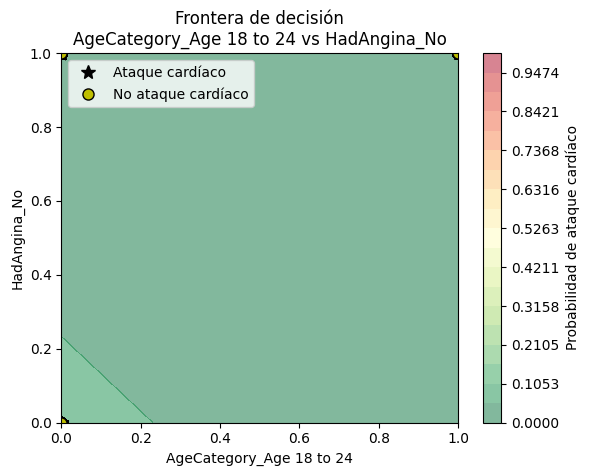

In [33]:
def plotDecisionBoundary(plotData, theta, X, y):
    theta = np.array(theta)

    columnas_X = data.drop('HadHeartAttack', axis=1).columns.tolist()

    # Usar las 2 features con mayor |theta| (excluyendo bias)
    theta_features = list(zip(columnas_X, theta[1:]))
    theta_ordenado = sorted(theta_features, key=lambda x: abs(x[1]), reverse=True)

    feat1, val1 = theta_ordenado[0]
    feat2, val2 = theta_ordenado[1]
    print(f"Features seleccionadas: {feat1} ({val1:.4f}), {feat2} ({val2:.4f})")

    idx1 = columnas_X.index(feat1) + 1
    idx2 = columnas_X.index(feat2) + 1

    # Graficar datos
    sample = data.sample(n=2000, random_state=1)
    X_plot = sample[[feat1, feat2]].values
    y_plot = sample['HadHeartAttack'].values

    fig = pyplot.figure()
    pos = y_plot == 1
    neg = y_plot == 0
    pyplot.plot(X_plot[pos, 0], X_plot[pos, 1], 'k*', lw=2, ms=10)
    pyplot.plot(X_plot[neg, 0], X_plot[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1)

    # Grilla
    f1_range = np.linspace(X[:, idx1].min(), X[:, idx1].max(), 100)
    f2_range = np.linspace(X[:, idx2].min(), X[:, idx2].max(), 100)

    z = np.zeros((len(f1_range), len(f2_range)))
    x_base = np.mean(X, axis=0).copy()

    for i, v1 in enumerate(f1_range):
        for j, v2 in enumerate(f2_range):
            x_temp = x_base.copy()
            x_temp[idx1] = v1
            x_temp[idx2] = v2
            z[i, j] = sigmoid(np.dot(x_temp, theta))

    z = z.T

    pyplot.contourf(f1_range, f2_range, z,
                    levels=np.linspace(0, 1, 20),
                    cmap='RdYlGn_r', alpha=0.5)
    pyplot.colorbar(label='Probabilidad de ataque cardíaco')
    pyplot.contour(f1_range, f2_range, z,
                   levels=[0.5], linewidths=2, colors='blue')

    pyplot.xlabel(feat1)
    pyplot.ylabel(feat2)
    pyplot.title(f'Frontera de decisión\n{feat1} vs {feat2}')
    pyplot.legend(['Ataque cardíaco', 'No ataque cardíaco'])
    pyplot.show()

plotDecisionBoundary(plotData, theta, X, y)

## Evaluación de regresión

In [34]:
def predict(theta, X):
    m = X.shape[0]
    p = np.zeros(m)
    p = (sigmoid(X.dot(theta)) >= 0.5).astype(int)
    return p

# Accuracy con theta optimizado por scipy
p = predict(theta, X)
accuracy = np.mean(p == y) * 100
print('Accuracy del modelo: {:.2f}%'.format(accuracy))

# Comparar con el descenso de gradiente manual
p_gd = predict(theta, X)
print('Accuracy esperado (aproximado): > 90%')

# Ejemplo individual
ejemplo = X[0]
prob = sigmoid(np.dot(ejemplo, theta))
pred = predict(theta, ejemplo.reshape(1, -1))[0]

print('\nEjemplo del dataset (fila 0):')
print('Probabilidad de ataque cardíaco: {:.2f}%'.format(prob * 100))
print('Predicción:', '⚠ Ataque cardíaco' if pred == 1 else '✓ No ataque cardíaco')
print('Real:      ', '⚠ Ataque cardíaco' if y[0] == 1 else '✓ No ataque cardíaco')

Accuracy del modelo: 94.87%
Accuracy esperado (aproximado): > 90%

Ejemplo del dataset (fila 0):
Probabilidad de ataque cardíaco: 1.07%
Predicción: ✓ No ataque cardíaco
Real:       ✓ No ataque cardíaco


In [36]:
def evaluar_riesgo_optimizado(theta, columnas):
    print("\n=== Evaluación de Riesgo de Ataque Cardíaco ===\n")

    x_input = np.zeros(len(columnas) + 1)
    x_input[0] = 1  # bias

    def set_val(col, val):
        if col in columnas:
            x_input[columnas.index(col) + 1] = val

    # ====== Datos numéricos ======
    bmi    = float(input("1) BMI (ej: 26.5): "))
    sleep  = float(input("2) Horas de sueño por noche (ej: 7): "))
    phys   = float(input("3) Días de mala salud física en el último mes (0-30): "))
    mental = float(input("4) Días de mala salud mental en el último mes (0-30): "))
    peso   = float(input("5) Peso en kg (ej: 75): "))
    altura = float(input("6) Altura en metros (ej: 1.75): "))

    set_val("BMI", bmi)
    set_val("SleepHours", sleep)
    set_val("PhysicalHealthDays", phys)
    set_val("MentalHealthDays", mental)
    set_val("WeightInKilograms", peso)
    set_val("HeightInMeters", altura)

    # ====== Sexo ======
    print("\n7) Sexo:")
    print("   1) Femenino   2) Masculino")
    sexo = input("Opción: ")
    if sexo == "1":
        set_val("Sex_Female", 1)
    elif sexo == "2":
        set_val("Sex_Male", 1)

    # ====== Salud general ======
    print("\n8) Salud general:")
    print("   1) Excelente  2) Muy buena  3) Buena  4) Regular  5) Mala")
    salud = input("Opción: ")
    opciones_salud = {
        "1": "GeneralHealth_Excellent",
        "2": "GeneralHealth_Very good",
        "3": "GeneralHealth_Good",
        "4": "GeneralHealth_Fair",
        "5": "GeneralHealth_Poor"
    }
    if salud in opciones_salud:
        set_val(opciones_salud[salud], 1)

    # ====== Edad ======
    print("\n9) Rango de edad:")
    print("   1) 18-24   2) 25-29   3) 30-34   4) 35-39   5) 40-44")
    print("   6) 45-49   7) 50-54   8) 55-59   9) 60-64   10) 65-69")
    print("   11) 70-74  12) 75-79  13) 80+")
    edad = input("Opción: ")
    opciones_edad = {
        "1": "AgeCategory_Age 18 to 24",
        "2": "AgeCategory_Age 25 to 29",
        "3": "AgeCategory_Age 30 to 34",
        "4": "AgeCategory_Age 35 to 39",
        "5": "AgeCategory_Age 40 to 44",
        "6": "AgeCategory_Age 45 to 49",
        "7": "AgeCategory_Age 50 to 54",
        "8": "AgeCategory_Age 55 to 59",
        "9": "AgeCategory_Age 60 to 64",
        "10": "AgeCategory_Age 65 to 69",
        "11": "AgeCategory_Age 70 to 74",
        "12": "AgeCategory_Age 75 to 79",
        "13": "AgeCategory_Age 80 or older"
    }
    if edad in opciones_edad:
        set_val(opciones_edad[edad], 1)

    # ====== Condiciones médicas ======
    print("\n10) ¿Le diagnosticaron angina? (s/n): ", end="")
    angina = input()
    set_val("HadAngina_Yes", 1 if angina.lower() == "s" else 0)
    set_val("HadAngina_No",  0 if angina.lower() == "s" else 1)

    print("11) ¿Tuvo un derrame cerebral? (s/n): ", end="")
    set_val("HadStroke_Yes", 1 if input().lower() == "s" else 0)

    print("12) ¿Tiene diabetes? (s/n): ", end="")
    set_val("HadDiabetes_Yes", 1 if input().lower() == "s" else 0)

    print("13) ¿Tiene EPOC o enfermedad pulmonar? (s/n): ", end="")
    set_val("HadCOPD_Yes", 1 if input().lower() == "s" else 0)

    print("14) ¿Tiene enfermedad renal? (s/n): ", end="")
    set_val("HadKidneyDisease_Yes", 1 if input().lower() == "s" else 0)

    print("15) ¿Tiene artritis? (s/n): ", end="")
    set_val("HadArthritis_Yes", 1 if input().lower() == "s" else 0)

    print("16) ¿Tuvo cáncer de piel? (s/n): ", end="")
    set_val("HadSkinCancer_Yes", 1 if input().lower() == "s" else 0)

    # ====== Hábitos ======
    print("\n17) ¿Fuma actualmente? (s/n): ", end="")
    fuma = input()
    if fuma.lower() == "s":
        set_val("SmokerStatus_Current smoker - now smokes every day", 1)
    else:
        set_val("SmokerStatus_Never smoked", 1)

    print("18) ¿Consume alcohol regularmente? (s/n): ", end="")
    set_val("AlcoholDrinkers_Yes", 1 if input().lower() == "s" else 0)

    print("19) ¿Tuvo COVID positivo? (s/n): ", end="")
    set_val("CovidPos_Yes", 1 if input().lower() == "s" else 0)

    print("20) ¿Realiza actividad física? (s/n): ", end="")
    set_val("PhysicalActivities_Yes", 1 if input().lower() == "s" else 0)

    # ====== Resultado ======
    prob = sigmoid(np.dot(x_input, theta))
    pred = 1 if prob >= 0.5 else 0

    print("\n" + "="*45)
    print("RESULTADO:")
    print(f"  Probabilidad de ataque cardíaco: {round(prob*100, 2)}%")
    print()
    if pred == 1:
        print("  ⚠ RIESGO ALTO — Se predice ataque cardíaco")
    else:
        print("  ✓ RIESGO BAJO — No se predice ataque cardíaco")
    print("="*45)

# Ejecutar con el theta optimizado por scipy
columnas = data.drop('HadHeartAttack', axis=1).columns.tolist()
evaluar_riesgo_optimizado(theta, columnas)


=== Evaluación de Riesgo de Ataque Cardíaco ===

1) BMI (ej: 26.5): 20
2) Horas de sueño por noche (ej: 7): 9
3) Días de mala salud física en el último mes (0-30): 10
4) Días de mala salud mental en el último mes (0-30): 12
5) Peso en kg (ej: 75): 72
6) Altura en metros (ej: 1.75): 1.80

7) Sexo:
   1) Femenino   2) Masculino
Opción: 2

8) Salud general:
   1) Excelente  2) Muy buena  3) Buena  4) Regular  5) Mala
Opción: 3

9) Rango de edad:
   1) 18-24   2) 25-29   3) 30-34   4) 35-39   5) 40-44
   6) 45-49   7) 50-54   8) 55-59   9) 60-64   10) 65-69
   11) 70-74  12) 75-79  13) 80+
Opción: 2

10) ¿Le diagnosticaron angina? (s/n): n
11) ¿Tuvo un derrame cerebral? (s/n): n
12) ¿Tiene diabetes? (s/n): n
13) ¿Tiene EPOC o enfermedad pulmonar? (s/n): n
14) ¿Tiene enfermedad renal? (s/n): n
15) ¿Tiene artritis? (s/n): n
16) ¿Tuvo cáncer de piel? (s/n): n

17) ¿Fuma actualmente? (s/n): n
18) ¿Consume alcohol regularmente? (s/n): n
19) ¿Tuvo COVID positivo? (s/n): n
20) ¿Realiza actividad